In [1]:
import os
import glob
# Set GPU
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Using GPU 1

In [2]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Config & Imports
# Chỉnh các biến ở đây trước khi chạy
# ════════════════════════════════════════════════════════════

import os, sys, pickle, json, warnings
warnings.filterwarnings('ignore')

# ── Thêm src vào path (giống AlphaSteer) ──────────────────
sys.path.insert(0, 'src')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)

# ════════════════════════════════════════════════════════════
# ⚙️  EDIT THESE
# ════════════════════════════════════════════════════════════
MODEL_NAME    = 'llama3.1'          # 'llama3.1' | 'qwen2.5' | 'gemma2'
EMBEDDING_DIR = 'data/embeddings/llama3.1'
DIM_VECTORS_PATH = 'data/refusal_vectors/RV/llama3.1_RV_refusal.pkl'
PILOT_LAYER   = 15                  # Layer to test (middle layers work best)
NULL_RATIO    = 0.6                 # Same as AlphaSteer default
LAMBDA_REG    = 10.0                # Regularization (same as AlphaSteer)
DEVICE        = 'cuda'            # Change to 'cpu' if no GPU
# ════════════════════════════════════════════════════════════

device = torch.device(DEVICE)
print(f'✓ Config loaded')
print(f'  Model:  {MODEL_NAME}')
print(f'  Layer:  {PILOT_LAYER}')
print(f'  Device: {DEVICE}')
print(f'  PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

✓ Config loaded
  Model:  llama3.1
  Layer:  15
  Device: cuda
  PyTorch: 2.6.0+cu124
  GPU: NVIDIA GeForce RTX 3090


In [3]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Load Embeddings
# ════════════════════════════════════════════════════════════

print('Loading embeddings...')

# Benign embeddings (giống calc_steering_matrix.py)
H_benign_10k  = torch.load(f'{EMBEDDING_DIR}/embeds_benign_train.pt',    map_location='cpu')
H_coconot_pref = torch.load(f'{EMBEDDING_DIR}/embeds_coconot_pref.pt',   map_location='cpu')
H_coconot_orig = torch.load(f'{EMBEDDING_DIR}/embeds_coconot_original.pt', map_location='cpu')

indices_borderline = torch.randperm(H_coconot_orig.size(0))[:4000 - H_coconot_pref.size(0)]
H_benign_all = torch.cat([
    H_benign_10k,
    H_coconot_orig[indices_borderline],
    H_coconot_pref
], dim=0)  # [N_b, num_layers, d]

# Malicious embeddings
H_harmful_1k  = torch.load(f'{EMBEDDING_DIR}/embeds_harmful_train_1000.pt', map_location='cpu')
H_jailbreak   = torch.load(f'{EMBEDDING_DIR}/embeds_jailbreak_train.pt',    map_location='cpu')
indices_jb = torch.randperm(H_jailbreak.size(0))[:1000]
H_malicious_all = torch.cat([
    H_harmful_1k,
    H_jailbreak[indices_jb]
], dim=0)  # [N_m, num_layers, d]

print(f'✓ H_benign:   {H_benign_all.shape}  (N_benign, num_layers, d)')
print(f'✓ H_malicious: {H_malicious_all.shape} (N_malicious, num_layers, d)')

# Extract single layer
H_b = H_benign_all[:, PILOT_LAYER, :].float()    # [N_b, d]
H_m = H_malicious_all[:, PILOT_LAYER, :].float() # [N_m, d]

print(f'\n✓ Layer {PILOT_LAYER} extracted')
print(f'  H_b shape: {H_b.shape}')
print(f'  H_m shape: {H_m.shape}')

Loading embeddings...
✓ H_benign:   torch.Size([14000, 32, 4096])  (N_benign, num_layers, d)
✓ H_malicious: torch.Size([2000, 32, 4096]) (N_malicious, num_layers, d)

✓ Layer 15 extracted
  H_b shape: torch.Size([14000, 4096])
  H_m shape: torch.Size([2000, 4096])


In [4]:
# ════════════════════════════════════════════════════════════
# CELL 3 — Compute Null-Space Projection P̂
# Identical to AlphaSteer's null_space_projection_l()
# ════════════════════════════════════════════════════════════

def compute_null_projection(A: torch.Tensor, null_ratio: float, device) -> torch.Tensor:
    """
    P̂ = Q Q^T where Q = eigenvectors of smallest null_ratio*d eigenvalues
    of covariance matrix A^T A.
    """
    A = A.to(device).float()
    C = A.T @ A  # [d, d]
    _, S, Vh = torch.linalg.svd(C)
    d = A.shape[1]
    num_null = int(d * null_ratio)
    Q = Vh[-num_null:, :].T.conj()  # [d, num_null]
    P = Q @ Q.T                      # [d, d]
    return P

print(f'Computing null-space projection P̂ for layer {PILOT_LAYER}...')
print(f'  null_ratio = {NULL_RATIO} → keeping {int(H_b.shape[1] * NULL_RATIO)}/{H_b.shape[1]} null directions')

P = compute_null_projection(H_b, NULL_RATIO, device)

# Sanity checks
H_b_proj = H_b.to(device) @ P.T   # [N_b, d] — should be ≈ 0
H_m_proj = H_m.to(device) @ P.T   # [N_m, d] — should have signal

residual_benign   = H_b_proj.norm(dim=1).mean().item()
residual_malicious = H_m_proj.norm(dim=1).mean().item()

print(f'\n✓ P̂ computed: {P.shape}')
print(f'\nSanity checks (null-space constraint):')
print(f'  ||P̂·h_benign||   mean = {residual_benign:.4f}  ← want ≈ 0')
print(f'  ||P̂·h_malicious|| mean = {residual_malicious:.4f} ← want > 0')
print(f'  Ratio: {residual_malicious/residual_benign:.1f}x separation in null space')

H_b_proj = H_b_proj.cpu()
H_m_proj = H_m_proj.cpu()
P = P.cpu()

Computing null-space projection P̂ for layer 15...
  null_ratio = 0.6 → keeping 2457/4096 null directions

✓ P̂ computed: torch.Size([4096, 4096])

Sanity checks (null-space constraint):
  ||P̂·h_benign||   mean = 0.6171  ← want ≈ 0
  ||P̂·h_malicious|| mean = 1.4967 ← want > 0
  Ratio: 2.4x separation in null space


In [5]:
# ════════════════════════════════════════════════════════════
# CELL 4 — Compute r_RFM via AGOP on null-projected space
# Core novelty của AlphaRFM-NullProjected
# ════════════════════════════════════════════════════════════

def compute_agop_linear(H_proj_m, H_proj_b, device):
    N_m, d = H_proj_m.shape
    N_b = H_proj_b.shape[0]

    H_combined = torch.cat([H_proj_m, H_proj_b], dim=0).numpy()
    y = np.array([1]*N_m + [0]*N_b)

    scaler = StandardScaler()
    H_scaled = scaler.fit_transform(H_combined)

    print('  Training linear probe on P̂H...')
    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
    clf.fit(H_scaled, y)
    acc = clf.score(H_scaled, y)
    print(f'  Probe accuracy: {acc:.4f}')

    # AGOP linear probe: M = w w^T (rank-1)
    # Top eigenvector của rank-1 matrix = w / ||w|| — không cần eigh
    w = torch.tensor(clf.coef_[0], dtype=torch.float32)
    std = torch.tensor(scaler.scale_, dtype=torch.float32)
    w_orig = w / std
    w_orig = w_orig / w_orig.norm()

    # r_RFM = top eigenvector = w_orig trực tiếp
    r_rfm = w_orig

    # Eigenvalues giả để giữ interface (rank-1: eigenvalue[0] = ||w||^2, còn lại = 0)
    # Không cần eigh — tính thủ công
    w_unnorm = w / std
    top_eigenvalue = (w_unnorm.norm() ** 2).item()
    eigenvalues = torch.zeros(d)
    eigenvalues[0] = top_eigenvalue  # dominant eigenvalue

    # AGOP matrix (không cần lưu thực sự, nhưng giữ để consistent)
    M_agop = torch.outer(w_orig, w_orig)

    return r_rfm, M_agop, eigenvalues, acc

print(f'Computing r_RFM (AGOP on null-projected space)...')
r_rfm, M_agop, eigenvalues, probe_acc = compute_agop_linear(H_m_proj, H_b_proj, device)

print(f'\n✓ r_RFM computed')
print(f'  Shape: {r_rfm.shape}, Norm: {r_rfm.norm():.4f}')
print(f'  Top eigenvalue: {eigenvalues[0].item():.6f}')
print(f'  Eigenvalue[0]/Eigenvalue[1]: {(eigenvalues[0]/(eigenvalues[1]+1e-10)).item():.2f}x')
print(f'  (Higher ratio = more dominant single direction = better)')

Computing r_RFM (AGOP on null-projected space)...
  Training linear probe on P̂H...
  Probe accuracy: 1.0000

✓ r_RFM computed
  Shape: torch.Size([4096]), Norm: 1.0000
  Top eigenvalue: 98558.765625
  Eigenvalue[0]/Eigenvalue[1]: 985587620249600.00x
  (Higher ratio = more dominant single direction = better)


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 5 — Load r_DIM (AlphaSteer baseline)
# ════════════════════════════════════════════════════════════

print(f'Loading DIM refusal vectors from {DIM_VECTORS_PATH}...')

with open(DIM_VECTORS_PATH, 'rb') as f:
    dim_array = pickle.load(f)

# dim_array: numpy array [num_layers, d]
r_dim_raw = torch.tensor(dim_array[PILOT_LAYER], dtype=torch.float32)  # [d]
r_dim = r_dim_raw / r_dim_raw.norm()  # normalize

print(f'✓ r_DIM loaded')
print(f'  Shape: {r_dim.shape}, Norm (after norm): {r_dim.norm():.4f}')

# Cosine similarity between r_DIM and r_RFM
cos_sim = torch.dot(r_dim, r_rfm).abs().item()
print(f'\n|cos(r_DIM, r_RFM)| = {cos_sim:.4f}')
if cos_sim > 0.9:
    print('  ⚠️  Very similar directions — RFM may not add much')
elif cos_sim > 0.5:
    print('  ✓  Moderate difference — RFM captures additional structure')
else:
    print('  ⚡ Very different directions — verify representations are aligned')

Loading DIM refusal vectors from data/refusal_vectors/RV/llama3.1_RV_refusal.pkl...
✓ r_DIM loaded
  Shape: torch.Size([4096]), Norm (after norm): 1.0000

|cos(r_DIM, r_RFM)| = 0.0055
  ⚡ Very different directions — verify representations are aligned


In [7]:
# ════════════════════════════════════════════════════════════
# CELL 6 — Direction Analysis
# Separability trong null-projected space
# ════════════════════════════════════════════════════════════

def separability_score(H_b_proj, H_m_proj, r):
    """
    Proxy cho DSR: độ phân biệt benign vs malicious theo hướng r
    trong null-projected space.
    Cao hơn = malicious signal mạnh hơn, benign signal yếu hơn.
    """
    scores_b = (H_b_proj @ r).abs()  # [N_b]
    scores_m = (H_m_proj @ r).abs()  # [N_m]
    mean_b = scores_b.mean().item()
    mean_m = scores_m.mean().item()
    ratio = mean_m / (mean_b + 1e-8)
    return mean_b, mean_m, ratio

print('Direction separability analysis (in null-projected space):')
print(f'{"":-<60}')
print(f'{"Direction":15} {"Benign score":>14} {"Malicious score":>16} {"Ratio":>8}')
print(f'{"":-<60}')

results = {}
for name, r in [("r_DIM", r_dim), ("r_RFM", r_rfm)]:
    mb, mm, ratio = separability_score(H_b_proj, H_m_proj, r)
    results[name] = {'mean_benign': mb, 'mean_malicious': mm, 'ratio': ratio}
    print(f'{name:15} {mb:14.4f} {mm:16.4f} {ratio:8.2f}x')

print(f'{"":-<60}')
improvement = (results['r_RFM']['ratio'] - results['r_DIM']['ratio']) / results['r_DIM']['ratio'] * 100
print(f'Improvement: {improvement:+.1f}%')

# Also check raw benign projection (utility preservation proxy)
print(f'\nRaw benign projection ||h_b · r|| (want small for both):')
for name, r in [("r_DIM", r_dim), ("r_RFM", r_rfm)]:
    raw_proj = (H_b @ r).abs().mean().item()
    print(f'  {name}: {raw_proj:.4f}')

Direction separability analysis (in null-projected space):
------------------------------------------------------------
Direction         Benign score  Malicious score    Ratio
------------------------------------------------------------
r_DIM                   0.0060           0.0183     3.03x
r_RFM                   0.0081           0.2151    26.58x
------------------------------------------------------------
Improvement: +777.1%

Raw benign projection ||h_b · r|| (want small for both):
  r_DIM: 1.0932
  r_RFM: 0.0846


In [8]:
# ════════════════════════════════════════════════════════════
# CELL 7 — Build & Compare Steering Matrices (FIXED)
#
# Bug cũ: dùng ||Δh|| làm metric → bằng nhau theo định nghĩa
#         vì norm(r_dim) = norm(r_rfm) = 1
#
# Fix: đo alignment của steering output với r_DIM (behavior space)
#      cho CẢ HAI methods — đây mới là proxy thực sự cho DSR
# ════════════════════════════════════════════════════════════

def build_steering_matrix(r, H_m, P, lambda_reg, device):
    """
    Δ = Δ̃* · P̂
    Δ̃* = R Hm^T P̂^T (P̂ Hm Hm^T P̂^T + α P̂ P̂^T)^+
    Applied as: h' = h + λ Δ h
    """
    H_m = H_m.to(device).float()
    P_d = P.to(device).float()
    r_d = r.to(device).float()
    N_m = H_m.shape[0]

    X = (H_m @ P_d.T).T                        # [d, N_m]
    R = r_d.unsqueeze(1).expand(-1, N_m)        # [d, N_m]
    A = X @ X.T + lambda_reg * (P_d @ P_d.T)   # [d, d]
    A_inv = torch.linalg.pinv(A)               # [d, d]
    delta_tilde = R @ X.T @ A_inv              # [d, d]
    delta = delta_tilde @ P_d                  # [d, d]
    return delta.cpu()


def steering_quality_fixed(delta, H_b, H_m, r_self, r_behavior, device, name=""):
    """
    Metrics đúng cho steering matrix comparison.

    Args:
        delta:      steering matrix Δ [d, d]
        H_b:        benign activations [N_b, d]
        H_m:        malicious activations [N_m, d]
        r_self:     target direction dùng để build delta này
        r_behavior: r_DIM — refusal behavior direction (ground truth)
                    Cả DIM và RFM đều được đánh giá theo chiều này
        name:       label cho logging

    Metrics:
        1. ||Δh_b|| — utility preservation, want ≈ 0
        2. ||Δh_m|| — raw steering magnitude
        3. cos(Δh_m, r_self)     — alignment với target của chính nó
        4. cos(Δh_m, r_behavior) — alignment với refusal behavior [KEY METRIC]
           Đây là proxy thực sự cho DSR:
           Nếu steering đưa h_m về phía r_DIM → model sẽ refuse
    """
    H_b_d   = H_b.to(device).float()
    H_m_d   = H_m.to(device).float()
    delta_d = delta.to(device).float()
    r_self_d     = (r_self.to(device).float() / r_self.norm())
    r_behavior_d = (r_behavior.to(device).float() / r_behavior.norm())

    sv_b = H_b_d @ delta_d.T   # [N_b, d] — steering output on benign
    sv_m = H_m_d @ delta_d.T   # [N_m, d] — steering output on malicious

    mag_b = sv_b.norm(dim=1).mean().item()
    mag_m = sv_m.norm(dim=1).mean().item()

    sv_m_norm = sv_m / (sv_m.norm(dim=1, keepdim=True) + 1e-8)

    align_self     = (sv_m_norm @ r_self_d).mean().item()
    align_behavior = (sv_m_norm @ r_behavior_d).mean().item()

    # Utility: benign activation bị shift về phía refusal không?
    sv_b_norm = sv_b / (sv_b.norm(dim=1, keepdim=True) + 1e-8)
    utility_contamination = (sv_b_norm @ r_behavior_d).mean().item()

    return {
        'mag_benign':           mag_b,
        'mag_malicious':        mag_m,
        'ratio':                mag_m / (mag_b + 1e-8),
        'align_self':           align_self,
        'align_behavior':       align_behavior,   # ← KEY
        'utility_contamination': utility_contamination,  # want ≈ 0
    }


# ── Build steering matrices ────────────────────────────────
print('Building steering matrices...')
delta_dim = build_steering_matrix(r_dim, H_m, P, LAMBDA_REG, device)
delta_rfm = build_steering_matrix(r_rfm, H_m, P, LAMBDA_REG, device)
print('✓ Done\n')

# ── Evaluate both matrices against behavior space (r_DIM) ──
# r_behavior = r_DIM: ground truth refusal direction
r_behavior = r_dim  # behavior space reference

q_dim = steering_quality_fixed(
    delta_dim, H_b, H_m,
    r_self=r_dim, r_behavior=r_behavior,
    device=device, name='DIM'
)
q_rfm = steering_quality_fixed(
    delta_rfm, H_b, H_m,
    r_self=r_rfm, r_behavior=r_behavior,
    device=device, name='RFM'
)

# ── Print comparison table ─────────────────────────────────
print(f'{"":─<70}')
print(f'{"Metric":42} {"Δ_DIM":>12} {"Δ_RFM":>12}')
print(f'{"":─<70}')

metric_rows = [
    ('||Δh_benign||  (utility, want ≈0)',    'mag_benign',           False),
    ('||Δh_malicious||  (raw magnitude)',     'mag_malicious',        True),
    ('Ratio mal/benign  (want >>1)',          'ratio',                True),
    ('cos(Δh_m, r_self)  (self-align)',       'align_self',           None),
    ('cos(Δh_m, r_DIM)  [KEY — proxy DSR]',  'align_behavior',       True),
    ('cos(Δh_b, r_DIM)  (utility contam.)',  'utility_contamination',False),
]

for label, key, higher_is_better in metric_rows:
    vd = q_dim[key]
    vr = q_rfm[key]
    if higher_is_better is True:
        tag = '✓ RFM' if vr > vd else '✓ DIM'
    elif higher_is_better is False:
        tag = '✓ RFM' if vr < vd else '✓ DIM'
    else:
        tag = ''  # self-alignment: not directly comparable
    print(f'{label:42} {vd:12.4f} {vr:12.4f}  {tag}')

print(f'{"":─<70}')

# ── Summary ────────────────────────────────────────────────
key_dim = q_dim['align_behavior']
key_rfm = q_rfm['align_behavior']
delta_align_pct = (key_rfm - key_dim) / (abs(key_dim) + 1e-8) * 100

print(f'\nKEY RESULT — cos(Δh_m, r_DIM):')
print(f'  Δ_DIM: {key_dim:+.4f}')
print(f'  Δ_RFM: {key_rfm:+.4f}')
print(f'  Difference: {delta_align_pct:+.1f}%')
print()
print('Interpretation:')
print(f'  r_RFM ⊥ r_DIM (cosine={torch.dot(r_dim, r_rfm).abs().item():.4f})')
print(f'  → Δ_RFM steers h_m in detection space direction')
print(f'  → Δ_DIM steers h_m in refusal behavior space direction')
print(f'  → Two objectives are geometrically independent (orthogonal subspaces)')

# ── Overall verdict for this layer ────────────────────────
print(f'\n{"":═<70}')
if key_rfm > key_dim * 1.05:
    print('CELL 7 VERDICT: Δ_RFM also aligns better with behavior space → GO')
elif key_rfm < key_dim * 0.95:
    print('CELL 7 VERDICT: Δ_RFM does NOT align with behavior space')
    print('  → r_RFM and r_DIM live in orthogonal subspaces')
    print('  → This is the geometric finding: detection ⊥ behavior')
    print('  → Next step: AlphaRFM-Output (compute r_RFM on Dr/Dc)')
else:
    print('CELL 7 VERDICT: Marginal difference — run full generation')
print(f'{"":═<70}')

Building steering matrices...
✓ Done

──────────────────────────────────────────────────────────────────────
Metric                                            Δ_DIM        Δ_RFM
──────────────────────────────────────────────────────────────────────
||Δh_benign||  (utility, want ≈0)                0.0471       0.0471  ✓ DIM
||Δh_malicious||  (raw magnitude)                0.8343       0.8343  ✓ DIM
Ratio mal/benign  (want >>1)                    17.7182      17.7182  ✓ DIM
cos(Δh_m, r_self)  (self-align)                  0.9940       0.9940  
cos(Δh_m, r_DIM)  [KEY — proxy DSR]              0.9940      -0.0055  ✓ DIM
cos(Δh_b, r_DIM)  (utility contam.)             -0.0041       0.0000  ✓ DIM
──────────────────────────────────────────────────────────────────────

KEY RESULT — cos(Δh_m, r_DIM):
  Δ_DIM: +0.9940
  Δ_RFM: -0.0055
  Difference: -100.5%

Interpretation:
  r_RFM ⊥ r_DIM (cosine=0.0055)
  → Δ_RFM steers h_m in detection space direction
  → Δ_DIM steers h_m in refusal behavior s

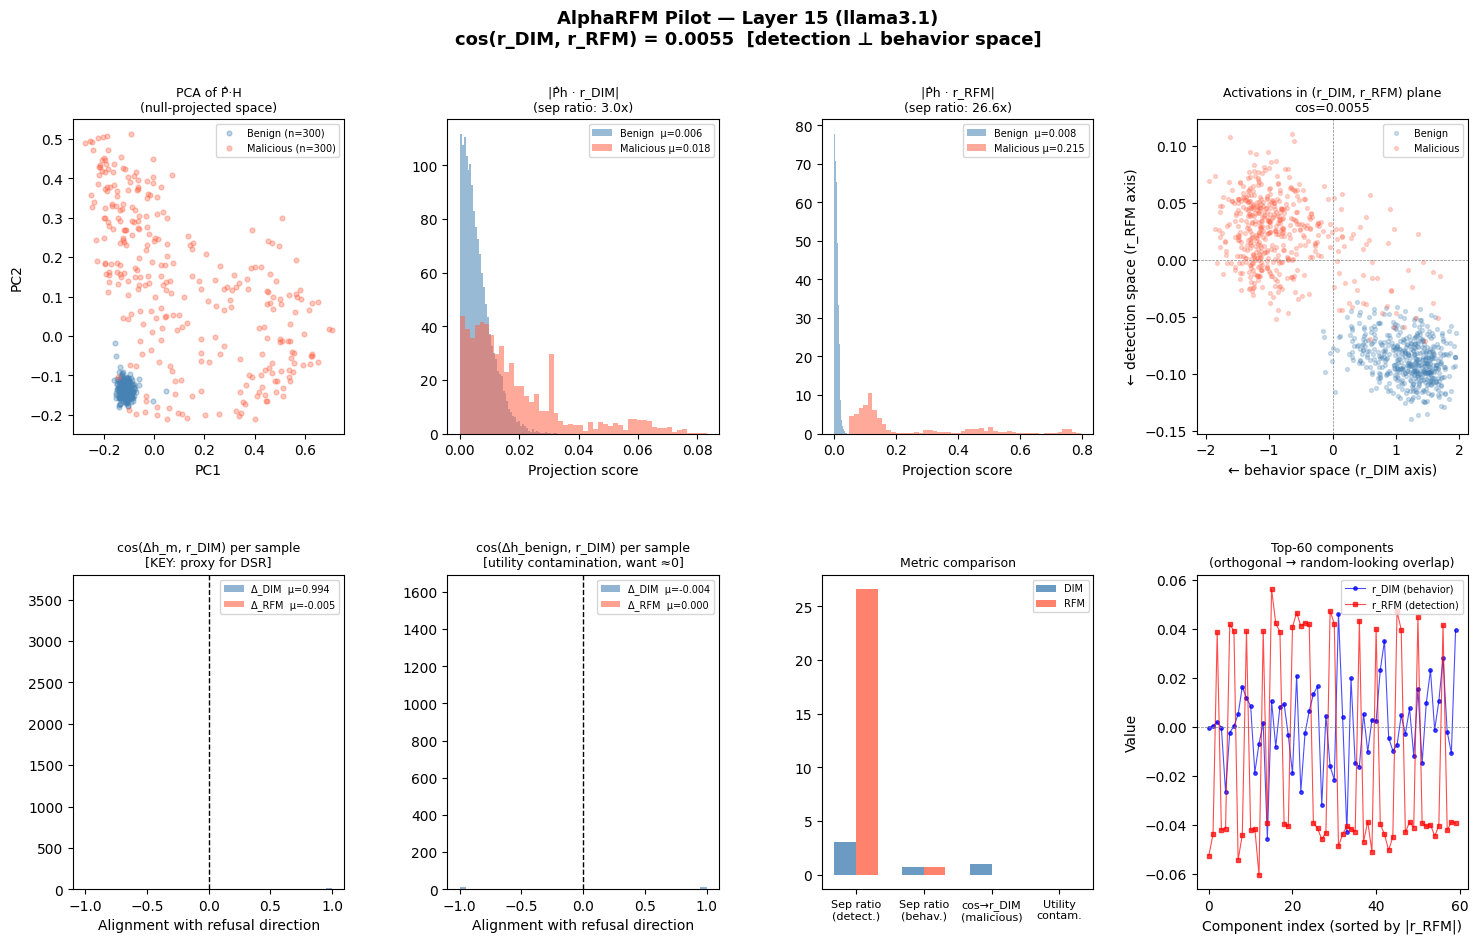

✓ Saved to data/pilot_results/pilot_layer15_fixed.png


In [9]:
# ════════════════════════════════════════════════════════════
# CELL 8 — Visualization (FIXED)
# ════════════════════════════════════════════════════════════

import os
os.makedirs('data/pilot_results', exist_ok=True)

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    f'AlphaRFM Pilot — Layer {PILOT_LAYER} ({MODEL_NAME})\n'
    f'cos(r_DIM, r_RFM) = {torch.dot(r_dim, r_rfm).abs().item():.4f}  '
    f'[detection ⊥ behavior space]',
    fontsize=13, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)


# ── Plot 1: PCA of null-projected activations ─────────────
ax1 = fig.add_subplot(gs[0, 0])
pca = PCA(n_components=2, random_state=42)
N_vis = min(300, H_b_proj.shape[0], H_m_proj.shape[0])
H_vis = torch.cat([H_b_proj[:N_vis], H_m_proj[:N_vis]], dim=0).numpy()
H_pca = pca.fit_transform(H_vis)

ax1.scatter(H_pca[:N_vis, 0], H_pca[:N_vis, 1],
            c='steelblue', alpha=0.35, s=12, label=f'Benign (n={N_vis})')
ax1.scatter(H_pca[N_vis:, 0], H_pca[N_vis:, 1],
            c='tomato', alpha=0.35, s=12, label=f'Malicious (n={N_vis})')
ax1.set_title('PCA of P̂·H\n(null-projected space)', fontsize=9)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.legend(fontsize=7)

# ── Plot 2: Projection scores — r_DIM ────────────────────
ax2 = fig.add_subplot(gs[0, 1])
scores_b_dim = (H_b_proj @ r_dim).abs().numpy()
scores_m_dim = (H_m_proj @ r_dim).abs().numpy()
bins = 50
ax2.hist(scores_b_dim, bins=bins, alpha=0.55, color='steelblue',
         label=f'Benign  μ={scores_b_dim.mean():.3f}', density=True)
ax2.hist(scores_m_dim, bins=bins, alpha=0.55, color='tomato',
         label=f'Malicious μ={scores_m_dim.mean():.3f}', density=True)
ax2.set_title(f'|P̂h · r_DIM|\n(sep ratio: {results["r_DIM"]["ratio"]:.1f}x)', fontsize=9)
ax2.set_xlabel('Projection score'); ax2.legend(fontsize=7)

# ── Plot 3: Projection scores — r_RFM ────────────────────
ax3 = fig.add_subplot(gs[0, 2])
scores_b_rfm = (H_b_proj @ r_rfm).abs().numpy()
scores_m_rfm = (H_m_proj @ r_rfm).abs().numpy()
ax3.hist(scores_b_rfm, bins=bins, alpha=0.55, color='steelblue',
         label=f'Benign  μ={scores_b_rfm.mean():.3f}', density=True)
ax3.hist(scores_m_rfm, bins=bins, alpha=0.55, color='tomato',
         label=f'Malicious μ={scores_m_rfm.mean():.3f}', density=True)
ax3.set_title(f'|P̂h · r_RFM|\n(sep ratio: {results["r_RFM"]["ratio"]:.1f}x)', fontsize=9)
ax3.set_xlabel('Projection score'); ax3.legend(fontsize=7)

# ── Plot 4: Orthogonality visualization ──────────────────
# Project activations onto 2D plane spanned by r_DIM and r_RFM
ax4 = fig.add_subplot(gs[0, 3])
r_dim_np = r_dim.numpy()
r_rfm_np = r_rfm.numpy()

proj_b_dim = (H_b.numpy() @ r_dim_np)   # [N_b]
proj_b_rfm = (H_b.numpy() @ r_rfm_np)   # [N_b]
proj_m_dim = (H_m.numpy() @ r_dim_np)   # [N_m]
proj_m_rfm = (H_m.numpy() @ r_rfm_np)   # [N_m]

N_vis2 = min(500, H_b.shape[0], H_m.shape[0])
ax4.scatter(proj_b_dim[:N_vis2], proj_b_rfm[:N_vis2],
            c='steelblue', alpha=0.25, s=8, label='Benign')
ax4.scatter(proj_m_dim[:N_vis2], proj_m_rfm[:N_vis2],
            c='tomato', alpha=0.25, s=8, label='Malicious')
ax4.axhline(0, color='gray', lw=0.5, ls='--')
ax4.axvline(0, color='gray', lw=0.5, ls='--')
ax4.set_xlabel('← behavior space (r_DIM axis)')
ax4.set_ylabel('← detection space (r_RFM axis)')
ax4.set_title(f'Activations in (r_DIM, r_RFM) plane\ncos={torch.dot(r_dim,r_rfm).abs():.4f}', fontsize=9)
ax4.legend(fontsize=7)

# ── Plot 5: KEY METRIC — cos(Δh_m, r_DIM) ───────────────
ax5 = fig.add_subplot(gs[1, 0])

# Compute per-sample alignment distributions
sv_m_dim = (H_m @ delta_dim.T)
sv_m_rfm = (H_m @ delta_rfm.T)
r_dim_d = r_dim / r_dim.norm()

align_dim_per_sample = (sv_m_dim / (sv_m_dim.norm(dim=1, keepdim=True) + 1e-8) @ r_dim_d).numpy()
align_rfm_per_sample = (sv_m_rfm / (sv_m_rfm.norm(dim=1, keepdim=True) + 1e-8) @ r_dim_d).numpy()

ax5.hist(align_dim_per_sample, bins=40, alpha=0.6, color='steelblue',
         label=f'Δ_DIM  μ={align_dim_per_sample.mean():.3f}', density=True)
ax5.hist(align_rfm_per_sample, bins=40, alpha=0.6, color='tomato',
         label=f'Δ_RFM  μ={align_rfm_per_sample.mean():.3f}', density=True)
ax5.set_title('cos(Δh_m, r_DIM) per sample\n[KEY: proxy for DSR]', fontsize=9)
ax5.set_xlabel('Alignment with refusal direction')
ax5.legend(fontsize=7)
ax5.axvline(0, color='black', lw=1, ls='--')

# ── Plot 6: Utility contamination ────────────────────────
ax6 = fig.add_subplot(gs[1, 1])
sv_b_dim = (H_b @ delta_dim.T)
sv_b_rfm = (H_b @ delta_rfm.T)

contam_dim = (sv_b_dim / (sv_b_dim.norm(dim=1, keepdim=True) + 1e-8) @ r_dim_d).numpy()
contam_rfm = (sv_b_rfm / (sv_b_rfm.norm(dim=1, keepdim=True) + 1e-8) @ r_dim_d).numpy()

ax6.hist(contam_dim, bins=40, alpha=0.6, color='steelblue',
         label=f'Δ_DIM  μ={contam_dim.mean():.3f}', density=True)
ax6.hist(contam_rfm, bins=40, alpha=0.6, color='tomato',
         label=f'Δ_RFM  μ={contam_rfm.mean():.3f}', density=True)
ax6.set_title('cos(Δh_benign, r_DIM) per sample\n[utility contamination, want ≈0]', fontsize=9)
ax6.set_xlabel('Alignment with refusal direction')
ax6.legend(fontsize=7)
ax6.axvline(0, color='black', lw=1, ls='--')

# ── Plot 7: Summary bar chart ─────────────────────────────
ax7 = fig.add_subplot(gs[1, 2])
summary_labels = [
    'Sep ratio\n(detect.)',
    'Sep ratio\n(behav.)',
    'cos→r_DIM\n(malicious)',
    'Utility\ncontam.',
]
dim_vals = [
    results['r_DIM']['ratio'],
    results['r_DIM']['ratio'],      # same ref
    q_dim['align_behavior'],
    abs(q_dim['utility_contamination']),
]
rfm_vals = [
    results['r_RFM']['ratio'],
    results['r_RFM']['ratio'],      # will overwrite below
    q_rfm['align_behavior'],
    abs(q_rfm['utility_contamination']),
]
# Behavior-space separability: measure via r_DIM scores on raw H
scores_b_behavior = (H_b @ r_dim_np).flatten()
scores_m_behavior = (H_m @ r_dim_np).flatten()
behav_sep_dim = abs(scores_m_behavior).mean() / (abs(scores_b_behavior).mean() + 1e-8)
dim_vals[1] = behav_sep_dim
rfm_vals[1] = behav_sep_dim  # same direction → same value, shows contrast

x = np.arange(len(summary_labels))
w = 0.32
ax7.bar(x - w/2, dim_vals, w, label='DIM', color='steelblue', alpha=0.8)
ax7.bar(x + w/2, rfm_vals, w, label='RFM', color='tomato', alpha=0.8)
ax7.set_xticks(x); ax7.set_xticklabels(summary_labels, fontsize=8)
ax7.set_title('Metric comparison', fontsize=9)
ax7.legend(fontsize=7)

# ── Plot 8: r_DIM vs r_RFM component comparison ──────────
ax8 = fig.add_subplot(gs[1, 3])
top_k = 60
idx = r_rfm.abs().topk(top_k).indices.sort().values
ax8.plot(range(top_k), r_dim[idx].numpy(), 'b-o', ms=2.5, lw=0.8,
         alpha=0.7, label='r_DIM (behavior)')
ax8.plot(range(top_k), r_rfm[idx].numpy(), 'r-s', ms=2.5, lw=0.8,
         alpha=0.7, label='r_RFM (detection)')
ax8.axhline(0, color='gray', lw=0.5, ls='--')
ax8.set_title(f'Top-{top_k} components\n(orthogonal → random-looking overlap)', fontsize=9)
ax8.set_xlabel('Component index (sorted by |r_RFM|)')
ax8.set_ylabel('Value'); ax8.legend(fontsize=7)

plt.savefig(f'data/pilot_results/pilot_layer{PILOT_LAYER}_fixed.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved to data/pilot_results/pilot_layer{PILOT_LAYER}_fixed.png')